# Лабораторная работа №2 — виртуальный датчик для печи обжига




In [1]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn lightgbm xgboost catboost optuna shap statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 27.5 MB/s eta 0:00:00


In [2]:
# Все импорты
from __future__ import annotations

import time
import warnings
from typing import Sequence, Tuple

import numpy as np
import pandas as pd

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from catboost import CatBoostRegressor
import lightgbm as lgb
import shap
import xgboost as xgb
from scipy import stats
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Палитра и оформление
COLOR_ACTUAL = "#2c3e50"
COLOR_PRED = "#d35400"
COLOR_ACCENT = "#16a085"
COLOR_GRID = "#ecf0f1"

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["grid.color"] = COLOR_GRID

RANDOM_STATE = 20
np.random.seed(RANDOM_STATE)

CONFIG = {
    "delay_candidates_min": [10, 11, 12, 13, 14, 15],
    "lag_list_min": [1, 5, 10, 15, 30, 60],
    "rolling_windows_min": [10, 20, 60],
    "train_fraction": 0.80,
    "delay_tune_n_estimators": 200,
    "optuna_trials": 18,
    "drop_col_missing_ratio_threshold": 0.95,
}

## 2.1 Разведочный анализ данных (EDA)

Загружаем минутную телеметрию и нерегулярные лабораторные точки, смотрим пропуски и целевую переменную.


In [5]:
# Загрузка
data_train = pd.read_csv("data_train.csv", parse_dates=["datetime"], index_col="datetime")
target_train = pd.read_csv("target_train.csv", parse_dates=["Дата"], index_col="Дата")
target_train.index.name = "datetime"
target_train.columns = ["target"]

data_test = pd.read_csv("data_test_small.csv", parse_dates=["datetime"], index_col="datetime")
target_test = pd.read_csv("target_test_small.csv", parse_dates=["Дата"], index_col="Дата")
target_test.index.name = "datetime"
target_test.columns = ["target"]

print("Телеметрия train:", data_train.info())
print("Цель train:", target_train.info())
print("Пропуски (телеметрия):\n", data_train.isnull().sum())
print("Пропуски target:", target_train.isnull().sum().values[0])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 319546 entries, 2019-03-01 00:01:00 to 2019-10-07 19:58:00
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   telemetry_0   319529 non-null  float64
 1   telemetry_1   319530 non-null  float64
 2   telemetry_2   319530 non-null  float64
 3   telemetry_3   319530 non-null  float64
 4   telemetry_4   319413 non-null  float64
 5   telemetry_5   319529 non-null  float64
 6   telemetry_6   319530 non-null  float64
 7   telemetry_7   319530 non-null  float64
 8   telemetry_8   319530 non-null  float64
 9   telemetry_9   319530 non-null  float64
 10  telemetry_10  319530 non-null  float64
 11  telemetry_11  319530 non-null  float64
 12  telemetry_12  2098 non-null    float64
 13  telemetry_13  2098 non-null    float64
 14  telemetry_14  2098 non-null    float64
 15  telemetry_15  2098 non-null    float64
dtypes: float64(16)
memory usage: 41.4 MB
Телеметрия train: Non

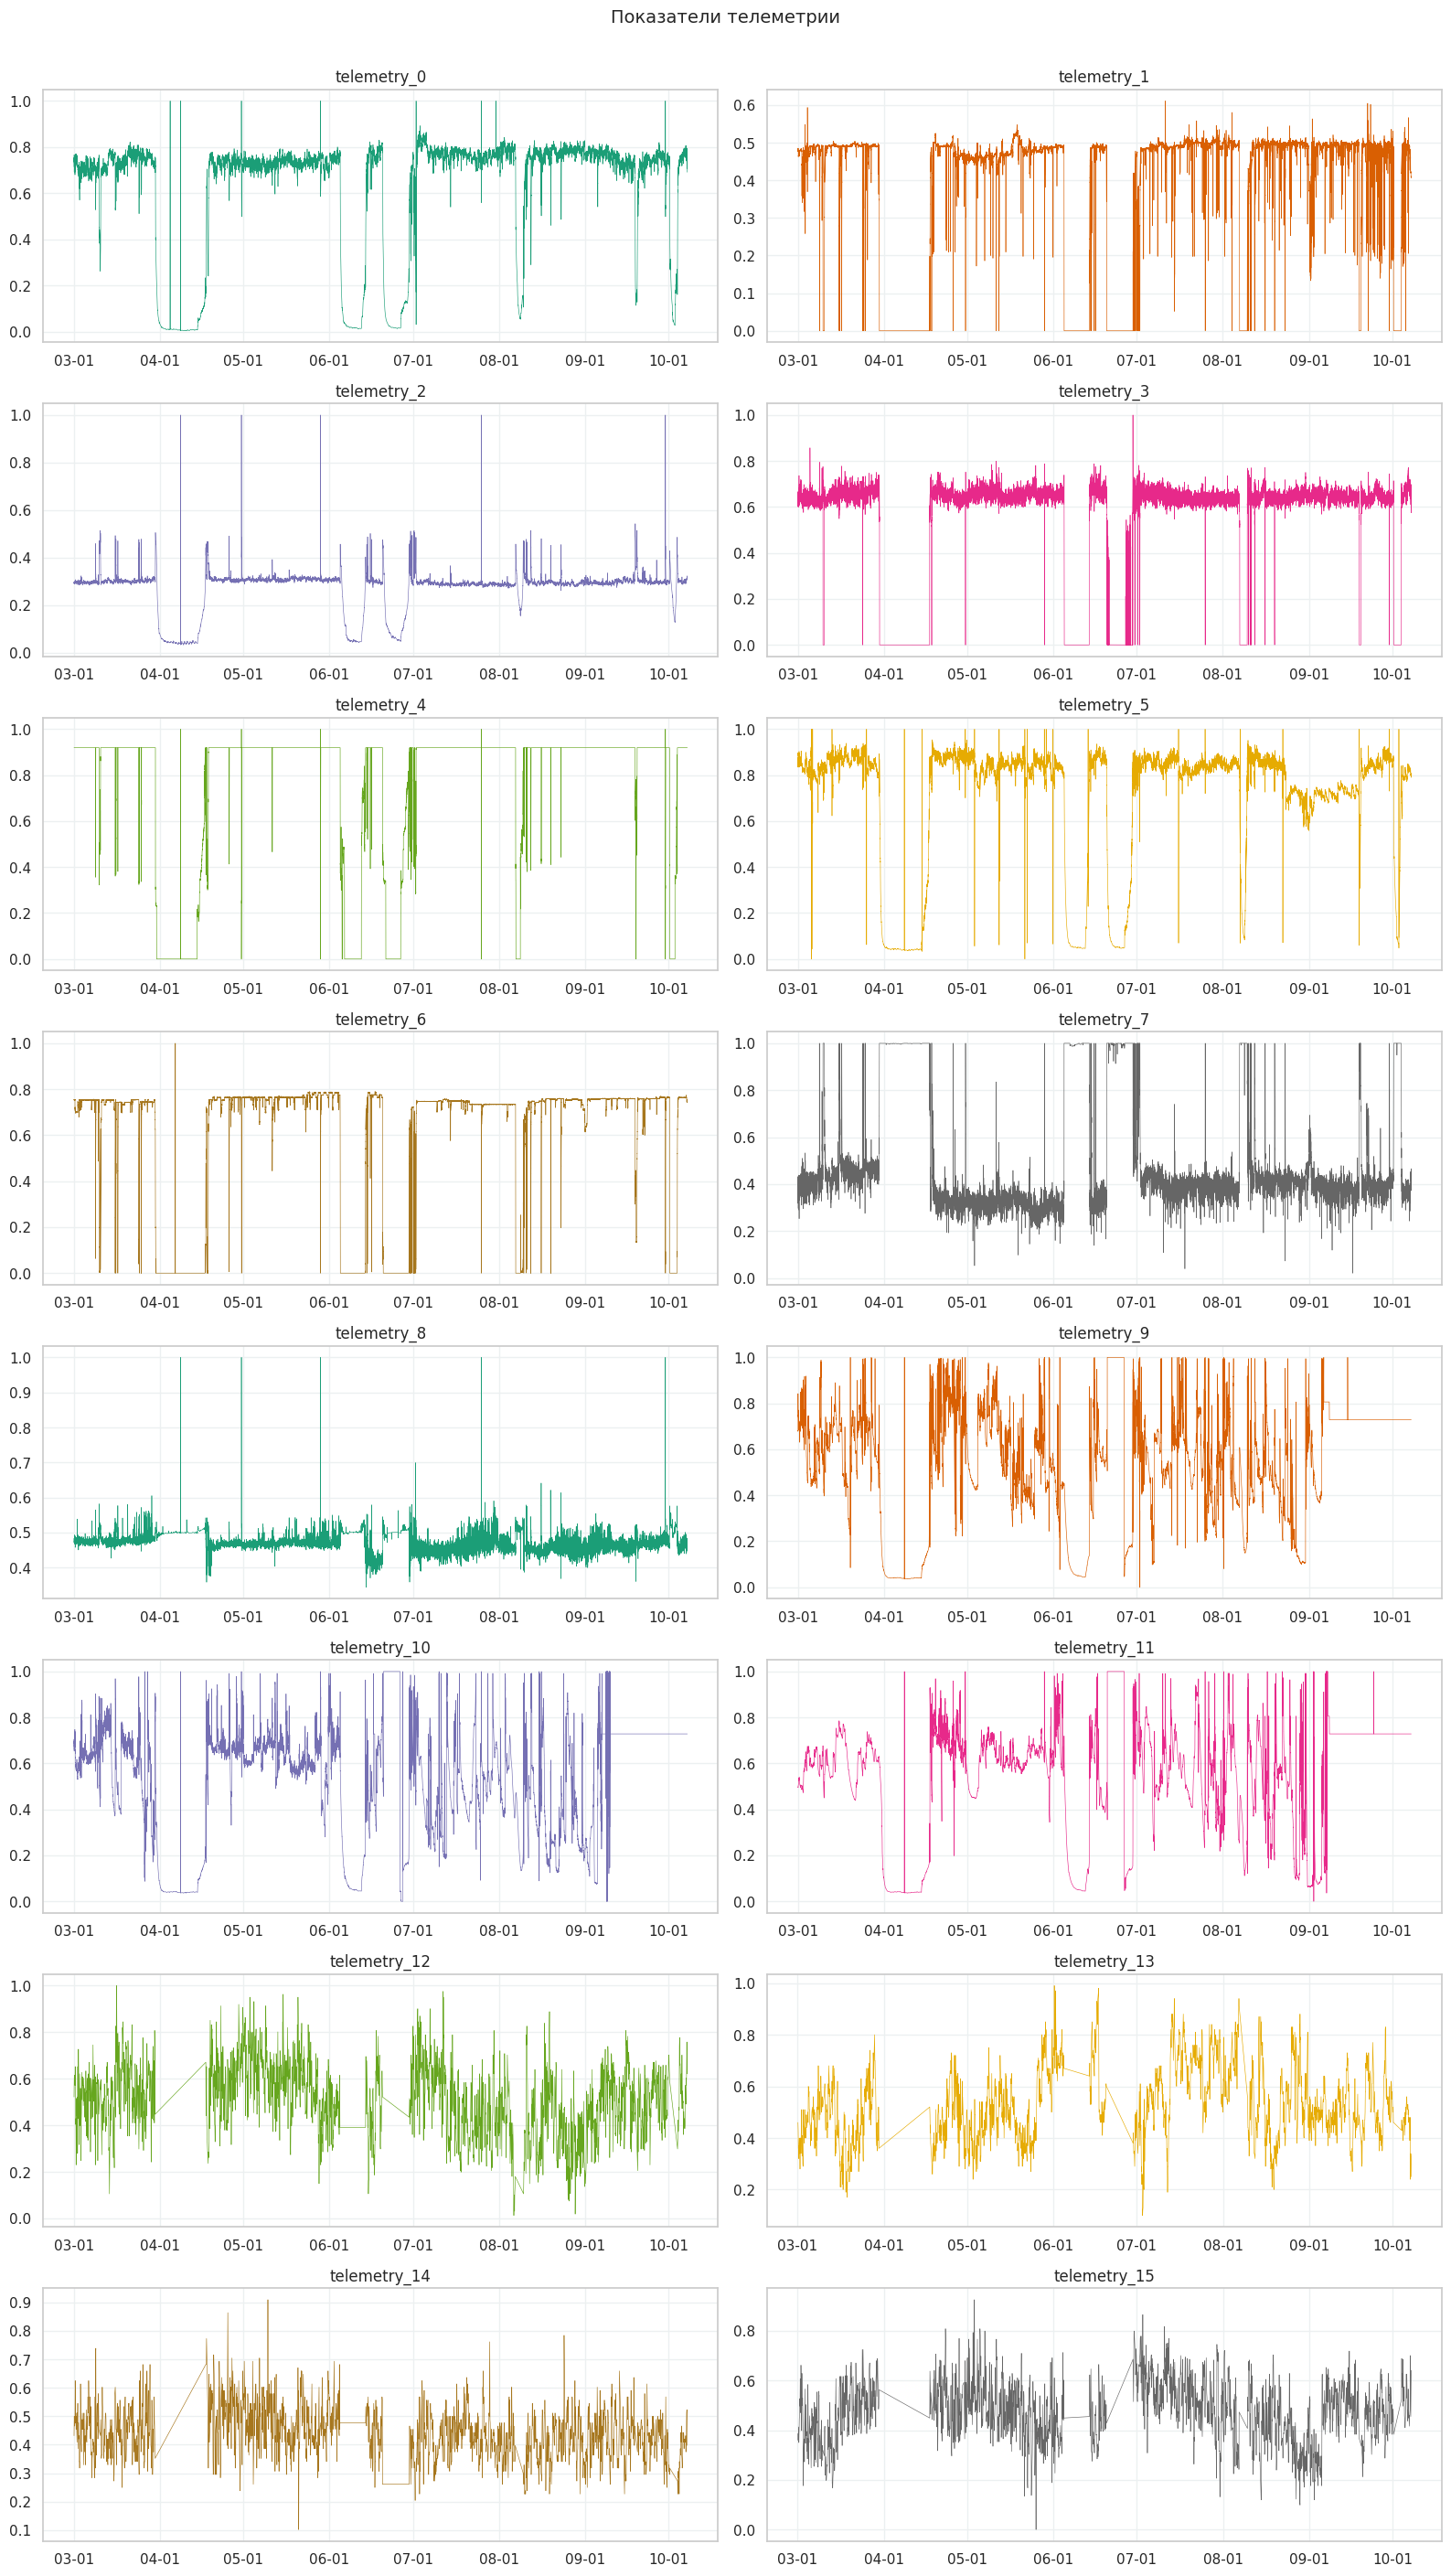

In [8]:
#  Показатели телеметрии
fig, axes = plt.subplots(8, 2, figsize=(16, 28))
axes = axes.flatten()
for i, col in enumerate(data_train.columns[:16]):
    ax = axes[i]
    s = data_train[col].dropna()
    ax.plot(s.index, s.values, lw=0.45, color=plt.cm.Dark2(i % 8))
    ax.set_title(col)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.suptitle("Показатели телеметрии", fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

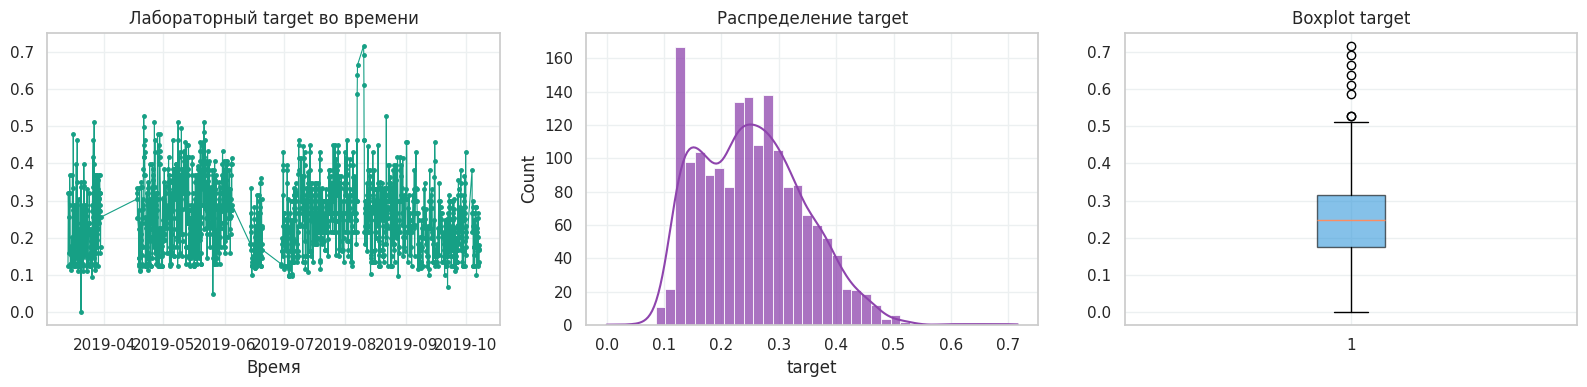

count    1773.0000
mean        0.2543
std         0.0922
min         0.0000
25%         0.1753
50%         0.2474
75%         0.3144
max         0.7165
Name: target, dtype: float64

Интервалы между лабораторными точками:
медиана: 0 days 02:00:00 | min: 0 days 01:00:00 | max: 18 days 08:30:00


In [13]:
# Целевая переменная
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(
    target_train.index, target_train["target"], marker="o", ms=2.5, lw=0.8, color=COLOR_ACCENT
)
axes[0].set_title("Лабораторный target во времени")
axes[0].set_xlabel("Время")

sns.histplot(target_train["target"], bins=42, color="#8e44ad", alpha=0.75, edgecolor="white", kde=True, ax=axes[1])
axes[1].set_title("Распределение target")
axes[2].boxplot(target_train["target"].dropna(), patch_artist=True,
                boxprops=dict(facecolor="#3498db", alpha=0.6))
axes[2].set_title("Boxplot target")
plt.tight_layout()
plt.show()

print(target_train["target"].describe().round(4))
gaps = target_train.index.to_series().diff().dropna()
print("\nИнтервалы между лабораторными точками:")
print("медиана:", gaps.median(), "| min:", gaps.min(), "| max:", gaps.max())

Массив телеметрических данных насчитывает примерно 320 тысяч записей и 16 показателей, которые регистрируются с большой периодичностью (около одного замера в минуту). При этом целевая характеристика измерена лишь 1773 раза, что указывает на редкое проведение лабораторных анализов, что и следует из тз.

Целевая переменная варьируется от ~0.2 до ~0.3, c выбросами от ~0.6 до ~0.7 (вероятно эти значение соответсвуют внештатным ситуациям). Её распределение выглядит отдаленно нормальным. Медиана интервала замеров — 2 часа.

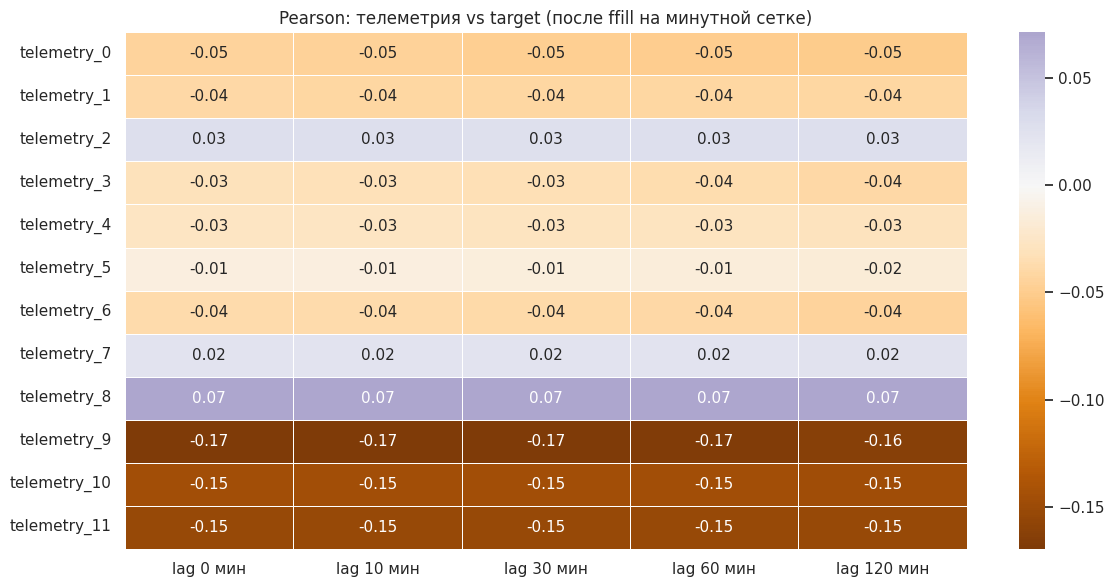

In [14]:
#  Корреляция телеметрии с target
TELE_COLS = [f"telemetry_{i}" for i in range(12)]
target_minute = target_train.reindex(data_train.index).ffill()
corr_lags = {}
for lag in [0, 10, 30, 60, 120]:
    shifted = target_minute.shift(-lag)
    corr_lags[lag] = data_train[TELE_COLS].corrwith(shifted["target"])
corr_df = pd.DataFrame(corr_lags)
corr_df.columns = [f"lag {c} мин" for c in corr_df.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="PuOr", center=0, linewidths=0.4, ax=ax)
ax.set_title("Pearson: телеметрия vs target (после ffill на минутной сетке)")
plt.tight_layout()
plt.show()

### Выводы по EDA

- Анализ пропущенных данных показал, что большинство признаков имеют высокую полноту заполнения, за исключением переменных telemetry_12–telemetry_15, где почти все значения отсутствуют. Вероятно, эти параметры либо фиксируются нечасто, либо слабо влияют на исследуемый процесс, поэтому в будущем их разумно исключить из traina для моделей.
- Остальные признаки имеют редкие пропуски; для производственной трактовки удобны интерполяция на коротких разрывах и усечение экстремумов по перцентилям.
- Анализ лагов показывает, что коэффициенты корреляции почти не изменяются при сдвиге от 0 до 120 минут. Это говорит об инерционности системы, поэтому использование временных окон длительностью в часы будет целесообразно
- Целевой ряд нерегулярный; перед объединением с телеметрией нужно явно учесть **задержку лаборатории** (см. следующий блок).
- Связь между признаками и целевой переменной слабая (абсолютные значения корреляции не превышают 0.18)
- telemetry_4 встречаются пропуски >10 мин —> применим заполенение медианой


In [18]:
#  Очистка телеметрии (train)
keep_cols = TELE_COLS
telemetry = data_train[keep_cols].copy()
telemetry = telemetry.groupby(telemetry.index, sort=True).mean(numeric_only=True)
telemetry = telemetry.interpolate(method="linear", limit=10)
for col in keep_cols:
    lo = telemetry[col].quantile(0.005)
    hi = telemetry[col].quantile(0.995)
    telemetry[col] = telemetry[col].clip(lo, hi)
if "telemetry_4" in telemetry.columns:
    med4 = telemetry["telemetry_4"].median()
    telemetry["telemetry_4"] = telemetry["telemetry_4"].fillna(med4)
    print("telemetry_4: длинные разрывы → медиана", round(med4, 4))

target = target_train.sort_index()
if target.index.has_duplicates:
    target = target.groupby(level=0).last()

print("Пропусков после очистки:", telemetry.isnull().sum().sum())

telemetry_4: длинные разрывы → медиана 0.9195
Пропусков после очистки: 0


### Синхронизация источников и выбор задержки

Лабораторный результат, приписанный времени `t`, отражает пробу, взятую примерно за **10–15 минут до готовности результата**. Чтобы не фиксировать задержку «на глаз», перебираем кандидатов **10…15 минут** и для каждого строим обучающую матрицу на якорных моментах `t_lab − delay`, затем сравниваем **MAE** на хронологическом отложенном фрагменте (ExtraTrees — быстрый прокси-модель для выбора `delay`).


 delay_min  n_samples      mae
        12       1772 0.080242
        13       1772 0.080797
        11       1772 0.080907
        14       1772 0.081355
        10       1772 0.081455
        15       1772 0.081535

Выбранная задержка (мин): 12


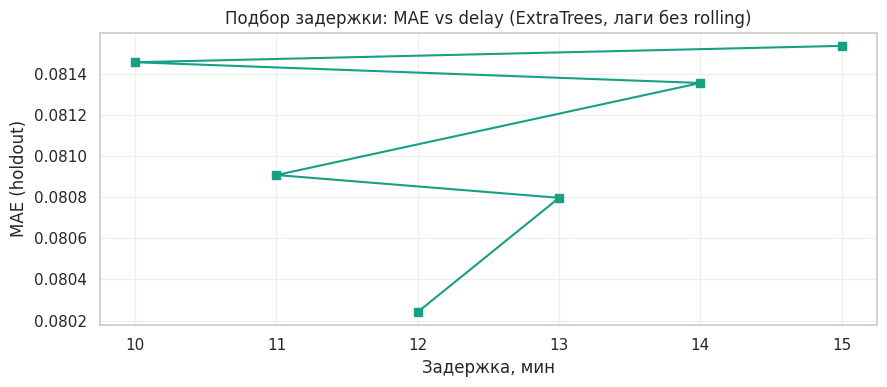

In [19]:
def build_supervised_dataset(
    telemetry_df: pd.DataFrame,
    target_df: pd.DataFrame,
    delay_min: int,
    lag_list_min: Sequence[int],
    rolling_windows_min: Sequence[int],
    telemetry_cols: Sequence[str],
    rolling_stats: Tuple[str, ...] = ("mean", "std", "min", "max"),
    include_derivatives: bool = False,
):
    """Признаки в моменты anchor = t_lab - delay_min (как в LR2)."""
    assert set(rolling_stats).issubset({"mean", "std", "min", "max"})
    anchor_times = target_df.index - pd.Timedelta(minutes=delay_min)

    X = {
        "hour_of_day": anchor_times.hour,
        "day_of_week": anchor_times.dayofweek,
        "month": anchor_times.month,
        "minute_of_hour": anchor_times.minute,
    }
    for col in telemetry_cols:
        s = telemetry_df[col]
        for lag in lag_list_min:
            t = anchor_times - pd.Timedelta(minutes=lag)
            X[f"{col}_lag_{lag}"] = s.reindex(t).to_numpy()
        if include_derivatives:
            X[f"{col}_diff_1"] = s.diff(1).reindex(anchor_times).to_numpy()
            X[f"{col}_pct_change_1"] = s.pct_change(1).replace([np.inf, -np.inf], np.nan).reindex(anchor_times).to_numpy()
        for w in rolling_windows_min:
            mp = max(2, w // 2)
            roll = s.rolling(w, min_periods=mp)
            if "mean" in rolling_stats:
                X[f"{col}_roll_mean_{w}"] = roll.mean().reindex(anchor_times).to_numpy()
            if "std" in rolling_stats:
                X[f"{col}_roll_std_{w}"] = roll.std().reindex(anchor_times).to_numpy()
            if "min" in rolling_stats:
                X[f"{col}_roll_min_{w}"] = roll.min().reindex(anchor_times).to_numpy()
            if "max" in rolling_stats:
                X[f"{col}_roll_max_{w}"] = roll.max().reindex(anchor_times).to_numpy()

    X_df = pd.DataFrame(X, index=target_df.index)
    y = target_df["target"].copy()
    valid = X_df.notna().all(axis=1)
    return X_df.loc[valid], y.loc[valid]


def time_split_by_fraction(X, y, frac: float):
    s = int(len(y) * frac)
    return X.iloc[:s], X.iloc[s:], y.iloc[:s], y.iloc[s:]


telemetry_cols_used = list(telemetry.columns)

delay_rows = []
for d in CONFIG["delay_candidates_min"]:
    Xd, yd = build_supervised_dataset(
        telemetry,
        target,
        d,
        CONFIG["lag_list_min"],
        CONFIG["rolling_windows_min"],
        telemetry_cols_used,
        rolling_stats=(),
        include_derivatives=False,
    )
    Xtr, Xte, ytr, yte = time_split_by_fraction(Xd, yd, CONFIG["train_fraction"])
    et = ExtraTreesRegressor(
        n_estimators=CONFIG["delay_tune_n_estimators"],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    et.fit(Xtr, ytr)
    delay_rows.append({"delay_min": d, "n_samples": len(yd), "mae": mean_absolute_error(yte, et.predict(Xte))})

res_delay = pd.DataFrame(delay_rows).sort_values("mae")
print(res_delay.to_string(index=False))
best_delay = int(res_delay.iloc[0]["delay_min"])
print(f"\nВыбранная задержка (мин): {best_delay}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(res_delay["delay_min"], res_delay["mae"], marker="s", color=COLOR_ACCENT, lw=1.5)
ax.set_xlabel("Задержка, мин")
ax.set_ylabel("MAE (holdout)")
ax.set_title("Подбор задержки: MAE vs delay (ExtraTrees, лаги без rolling)")
plt.tight_layout()
plt.show()

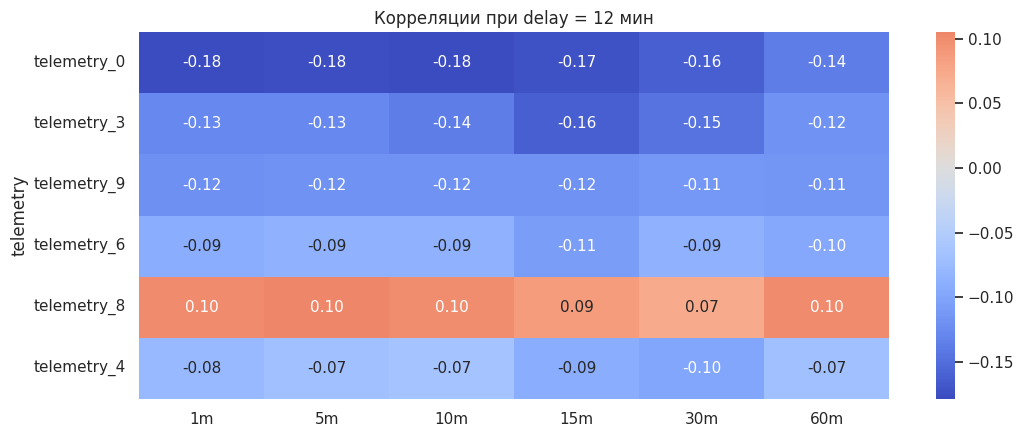

In [20]:
#  Корреляции target vs телеметрия при выбранной задержке
anchor_times = target.index - pd.Timedelta(minutes=best_delay)
lag_list = CONFIG["lag_list_min"]
corr_rows = []
for col in telemetry.columns:
    row = {"telemetry": col}
    for lag in lag_list:
        t = anchor_times - pd.Timedelta(minutes=lag)
        vals = telemetry[col].reindex(t).to_numpy()
        yv = target["target"].to_numpy()
        m = np.isfinite(vals) & np.isfinite(yv)
        row[f"lag_{lag}"] = (
            np.corrcoef(vals[m], yv[m])[0, 1] if m.sum() >= 30 else np.nan
        )
    corr_rows.append(row)
corr_lab = pd.DataFrame(corr_rows).set_index("telemetry")
absmax = corr_lab.abs().max(axis=1).sort_values(ascending=False)
top6 = absmax.head(6).index
heat = corr_lab.loc[top6].rename(columns={f"lag_{l}": f"{l}m" for l in lag_list})

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title(f"Корреляции при delay = {best_delay} мин")
plt.tight_layout()
plt.show()

### Обоснование обработки пропусков и выбросов

- **Короткие провалы** в штатной телеметрии разумно закрывать локальной интерполяцией: оператор всё равно видит «сглаженную» картину по соседним минутам.
- **Пропуски в телеметрических данных** восполняются с помощью временной интерполяции. Такой подход оправдан физически — процесс обжига обладает непрерывностью и инерционностью. Для обработки аномальных значений используется винзоризация (ограничение) по 5-му и 95-му процентилям. Это позволяет уменьшить влияние технических сбоев датчиков, сохранив при этом реальные технологические отклонения, что в итоге повышает устойчивость прогнозных моделей.
- **Синхронизация** через `t_lab − delay` соответствует физике: признаки берутся в момент отбора пробы, а не в момент публикации протокола.


## 2.2 Инжиниринг признаков для рядов

Полная матрица: лаги по минутам из `CONFIG`, скользящие mean/std/min/max, при необходимости — приращения; затем добавляем **авторегрессионные лаги target** (прошлые лабораторные значения на той же нерегулярной сетке), что обычно сильно повышает качество.


Размерность: (1759, 247) | целевая: (1759,)

Топ-15 |corr| с target:
 target_lab_lag1             0.5379
target_lab_lag2             0.3292
target_lab_lag3             0.2162
telemetry_0_roll_max_60     0.1425
telemetry_0_roll_max_10     0.1419
telemetry_0_roll_max_20     0.1416
telemetry_0_lag_1           0.1404
telemetry_0_roll_mean_10    0.1382
telemetry_0_lag_10          0.1371
telemetry_0_lag_5           0.1369
telemetry_0_roll_mean_20    0.1361
telemetry_0_roll_min_10     0.1358
telemetry_9_roll_min_60     0.1334
telemetry_0_lag_15          0.1322
telemetry_0_roll_min_20     0.1276
Name: target, dtype: float64


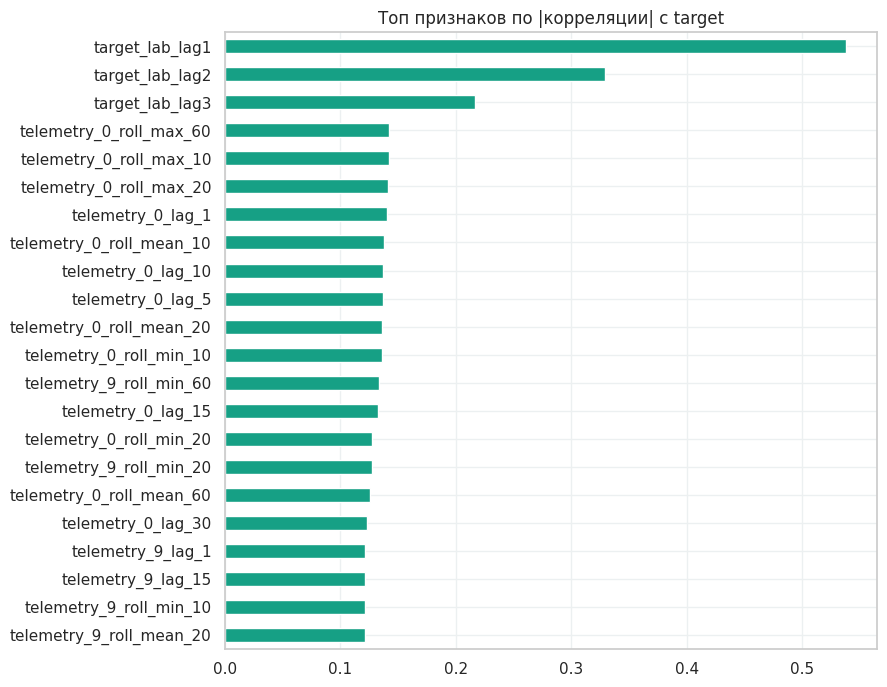

In [21]:
X_all, y_all = build_supervised_dataset(
    telemetry,
    target,
    best_delay,
    CONFIG["lag_list_min"],
    CONFIG["rolling_windows_min"],
    telemetry_cols_used,
    rolling_stats=("mean", "std", "min", "max"),
    include_derivatives=True,
)

for k in (1, 2, 3):
    X_all[f"target_lab_lag{k}"] = y_all.shift(k)

X_all = X_all.join(y_all.rename("y_tmp"))
mask = X_all.notna().all(axis=1)
X_all = X_all.loc[mask].drop(columns=["y_tmp"])
y_all = y_all.loc[X_all.index]

feature_cols = [c for c in X_all.columns]
print("Размерность:", X_all.shape, "| целевая:", y_all.shape)

abs_corr = X_all.assign(target=y_all).corr()["target"].drop("target").abs().sort_values(ascending=False)
print("\nТоп-15 |corr| с target:\n", abs_corr.head(15).round(4))

fig, ax = plt.subplots(figsize=(9, 7))
abs_corr.head(22).sort_values().plot(kind="barh", ax=ax, color=COLOR_ACCENT)
ax.set_title("Топ признаков по |корреляции| с target")
plt.tight_layout()
plt.show()


### Замечание по отбору признаков

Здесь признаки **интерпретируемы** (конкретный датчик, лаг или окно сглаживания). При необходимости можно добавить PCA для сжатия, но для объяснимости оператору чаще полезнее **отбор по важности** (SHAP / перестановки) после обучения деревьев.


В итоге работы над признаками для временных рядов был сформирован набор дополнительных характеристик, позволяющих модели лучше улавливать динамику процесса обжига:

- **Лаговые переменные** — они добавляют в модель информацию о предыдущих значениях телеметрии. Это важно, поскольку воздействие параметров на конечную концентрацию продукта проявляется с некоторым запаздыванием. Оптимальные лаги, дающие наибольшую корреляцию с целевым показателем, были выявлены на предварительном этапе анализа.

- **Скользящие статистики** (среднее, стандартное отклонение, минимумы и максимумы) рассчитывались на временных окнах длиной 5, 10 и 30 минут. Они отражают локальные тренды и разброс параметров внутри печи, а также делают модель менее чувствительной к шумам в данных.

- **Показатели динамики** (разности и относительные изменения) фиксируют, с какой скоростью и в каком направлении меняются телеметрические параметры. Это помогает обнаруживать резкие колебания процесса, которые могут повлиять на качество выпускаемой продукции.

Все созданные признаки легко интерпретируются: каждый из них соответствует реальному физическому процессу, происходящему в печи, и имеет прямое технологическое обоснование.


## 2.3 Прогнозные модели

**Что берём в сравнение**

1. **Ridge** — быстрый линейный baseline с масштабированием признаков.
2. **LightGBM** и **XGBoost** — градиентный бустинг по табличным признакам, хорошо улавливает нелинейности и взаимодействия.
3. **RandomForest** — ансамбль деревьев, устойчив к шуму, слабее тюнится, но даёт устойчивую базу.
4. **CatBoost** — бустинг с устойчивостью к разным масштабам и типичным настройкам по умолчанию.

Гиперпараметры для **LightGBM, XGBoost, CatBoost и RandomForest** подбираем через **Optuna** (минимизация MAE на валидационном «хвосте» обучающего интервала; без перемешивания).

**Что намеренно не используем как основной вариант**

- **ARIMA / SARIMA** — хотя это классические модели для временных рядов, они плохо справляются с большим количеством внешних признаков и не учитывают сложные взаимодействия между параметрами печи.
- **Prophet и ETS** предназначены для одномерных рядов и ориентированы на тренд и сезонность. В нашем случае нет выраженной сезонности, а основной сигнал поступает от многомерной телеметрии.
- **Классические RNN/LSTM** на столь короткой выборке лабораторных точек — высокий риск переобучения. Возможны как исследовательский эксперимент, не как базовая модель.


In [22]:
split = int(len(y_all) * CONFIG["train_fraction"])
X_train, X_test = X_all.iloc[:split], X_all.iloc[split:]
y_train, y_test = y_all.iloc[:split], y_all.iloc[split:]
print("Train:", X_train.shape, "| Test:", X_test.shape)

val_frac = 0.15
v = int(len(X_train) * (1 - val_frac))
X_tr, X_val = X_train.iloc[:v], X_train.iloc[v:]
y_tr, y_val = y_train.iloc[:v], y_train.iloc[v:]


def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


def mape_safe(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))


def directional_accuracy(y_true: pd.Series, y_pred: np.ndarray) -> float:
    td = np.diff(y_true.values)
    pd_ = np.diff(y_pred)
    return float(np.mean(np.sign(td) == np.sign(pd_)))


def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    out = {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape_safe(y_true.values, y_pred),
        "WAPE": wape(y_true.values, y_pred),
        "DA": directional_accuracy(y_true, y_pred),
    }
    print(f"\n{name}\n  MAE={mae:.5f} RMSE={rmse:.5f} MAPE={out['MAPE']:.5f} WAPE={out['WAPE']:.5f} DA={out['DA']:.4f}")
    return out



Train: (1407, 247) | Test: (352, 247)


In [23]:
#  Optuna: LightGBM
def objective_lgb(trial: optuna.Trial) -> float:
    params = {
        "objective": "regression",
        "metric": "mae",
        "verbosity": -1,
        "random_state": RANDOM_STATE,
        "n_estimators": 800,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 24, 96),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
    )
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)


study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(objective_lgb, n_trials=CONFIG["optuna_trials"], show_progress_bar=False)
lgb_params = study_lgb.best_params.copy()
lgb_params.update({"objective": "regression", "metric": "mae", "verbosity": -1, "random_state": RANDOM_STATE, "n_estimators": 1200})
print("Best LGB trial MAE:", study_lgb.best_value, "| params:", study_lgb.best_params)

lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(120, verbose=False), lgb.log_evaluation(0)],
)
y_pred_lgb = lgb_model.predict(X_test)
res_lgb = evaluate("LightGBM (Optuna)", y_test, y_pred_lgb)

Best LGB trial MAE: 0.056870567138824865 | params: {'learning_rate': 0.03546964018521773, 'num_leaves': 37, 'min_child_samples': 77, 'subsample': 0.6553956847472384, 'colsample_bytree': 0.6549342810464229, 'reg_alpha': 0.004030486926928829, 'reg_lambda': 0.018147138830185264}

LightGBM (Optuna)
  MAE=0.06193 RMSE=0.07684 MAPE=0.33045 WAPE=0.27437 DA=0.4188


In [24]:
#  Optuna: XGBoost
def objective_xgb(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": 800,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 12.0),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "random_state": RANDOM_STATE,
        "verbosity": 0,
    }
    model = xgb.XGBRegressor(**params, early_stopping_rounds=70)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)


study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 1))
study_xgb.optimize(objective_xgb, n_trials=CONFIG["optuna_trials"], show_progress_bar=False)
xp = study_xgb.best_params.copy()
xp.update({"n_estimators": 1500, "random_state": RANDOM_STATE, "verbosity": 0})
print("Best XGB trial MAE:", study_xgb.best_value)

xgb_model = xgb.XGBRegressor(**xp)
xgb_model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
)
y_pred_xgb = xgb_model.predict(X_test)
res_xgb = evaluate("XGBoost (Optuna)", y_test, y_pred_xgb)

Best XGB trial MAE: 0.05783796933528701

XGBoost (Optuna)
  MAE=0.05894 RMSE=0.07503 MAPE=0.30103 WAPE=0.26113 DA=0.4274


In [25]:
#  Optuna: CatBoost
def objective_cat(trial: optuna.Trial) -> float:
    params = {
        "iterations": 900,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.5, 5.0),
        "loss_function": "MAE",
        "verbose": False,
        "random_seed": RANDOM_STATE,
        "allow_writing_files": False,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=80, verbose=False)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)


study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 2))
study_cat.optimize(objective_cat, n_trials=CONFIG["optuna_trials"], show_progress_bar=False)
cp = study_cat.best_params.copy()
cp.update({"iterations": 2000, "loss_function": "MAE", "verbose": False, "random_seed": RANDOM_STATE, "allow_writing_files": False})
print("Best CatBoost trial MAE:", study_cat.best_value)

cat_model = CatBoostRegressor(**cp)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=120, verbose=False)
y_pred_cat = cat_model.predict(X_test)
res_cat = evaluate("CatBoost (Optuna)", y_test, y_pred_cat)

Best CatBoost trial MAE: 0.05927690071350381

CatBoost (Optuna)
  MAE=0.05763 RMSE=0.07312 MAPE=0.30208 WAPE=0.25532 DA=0.4387


In [26]:
#  Optuna: RandomForest
def objective_rf(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 8, 28),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 20),
        "max_features": trial.suggest_float("max_features", 0.35, 0.9),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)


study_rf = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 3))
study_rf.optimize(objective_rf, n_trials=max(12, CONFIG["optuna_trials"] // 2), show_progress_bar=False)
rf_params = study_rf.best_params.copy()
print("Best RF trial MAE:", study_rf.best_value)

rf_model = RandomForestRegressor(**rf_params, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
res_rf = evaluate("RandomForest (Optuna)", y_test, y_pred_rf)

Best RF trial MAE: 0.05741248142222681

RandomForest (Optuna)
  MAE=0.05864 RMSE=0.07306 MAPE=0.31902 WAPE=0.25980 DA=0.3989


In [44]:
#  Ridge (без Optuna - перебирал сам несколько раз)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
ridge = Ridge(alpha=6.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)
res_ridge = evaluate("Ridge", y_test, y_pred_ridge)


Ridge
  MAE=0.13134 RMSE=0.69013 MAPE=0.76140 WAPE=0.58189 DA=0.4188


In [45]:
summary = pd.DataFrame([res_ridge, res_lgb, res_xgb, res_cat, res_rf]).set_index("model").round(5)
print("\n=== Сводка по отложенному интервалу ===\n", summary.to_string())

best_name = summary["MAE"].idxmin()
key_map = {
    "Ridge": y_pred_ridge,
    "LightGBM (Optuna)": y_pred_lgb,
    "XGBoost (Optuna)": y_pred_xgb,
    "CatBoost (Optuna)": y_pred_cat,
    "RandomForest (Optuna)": y_pred_rf,
}
best_pred = key_map[best_name]
print("\nЛучшая модель по MAE:", best_name)


=== Сводка по отложенному интервалу ===
                            MAE     RMSE     MAPE     WAPE       DA
model                                                             
Ridge                  0.13134  0.69013  0.76140  0.58189  0.41880
LightGBM (Optuna)      0.06193  0.07684  0.33045  0.27437  0.41880
XGBoost (Optuna)       0.05894  0.07503  0.30103  0.26113  0.42735
CatBoost (Optuna)      0.05763  0.07312  0.30208  0.25532  0.43875
RandomForest (Optuna)  0.05864  0.07306  0.31902  0.25980  0.39886

Лучшая модель по MAE: CatBoost (Optuna)


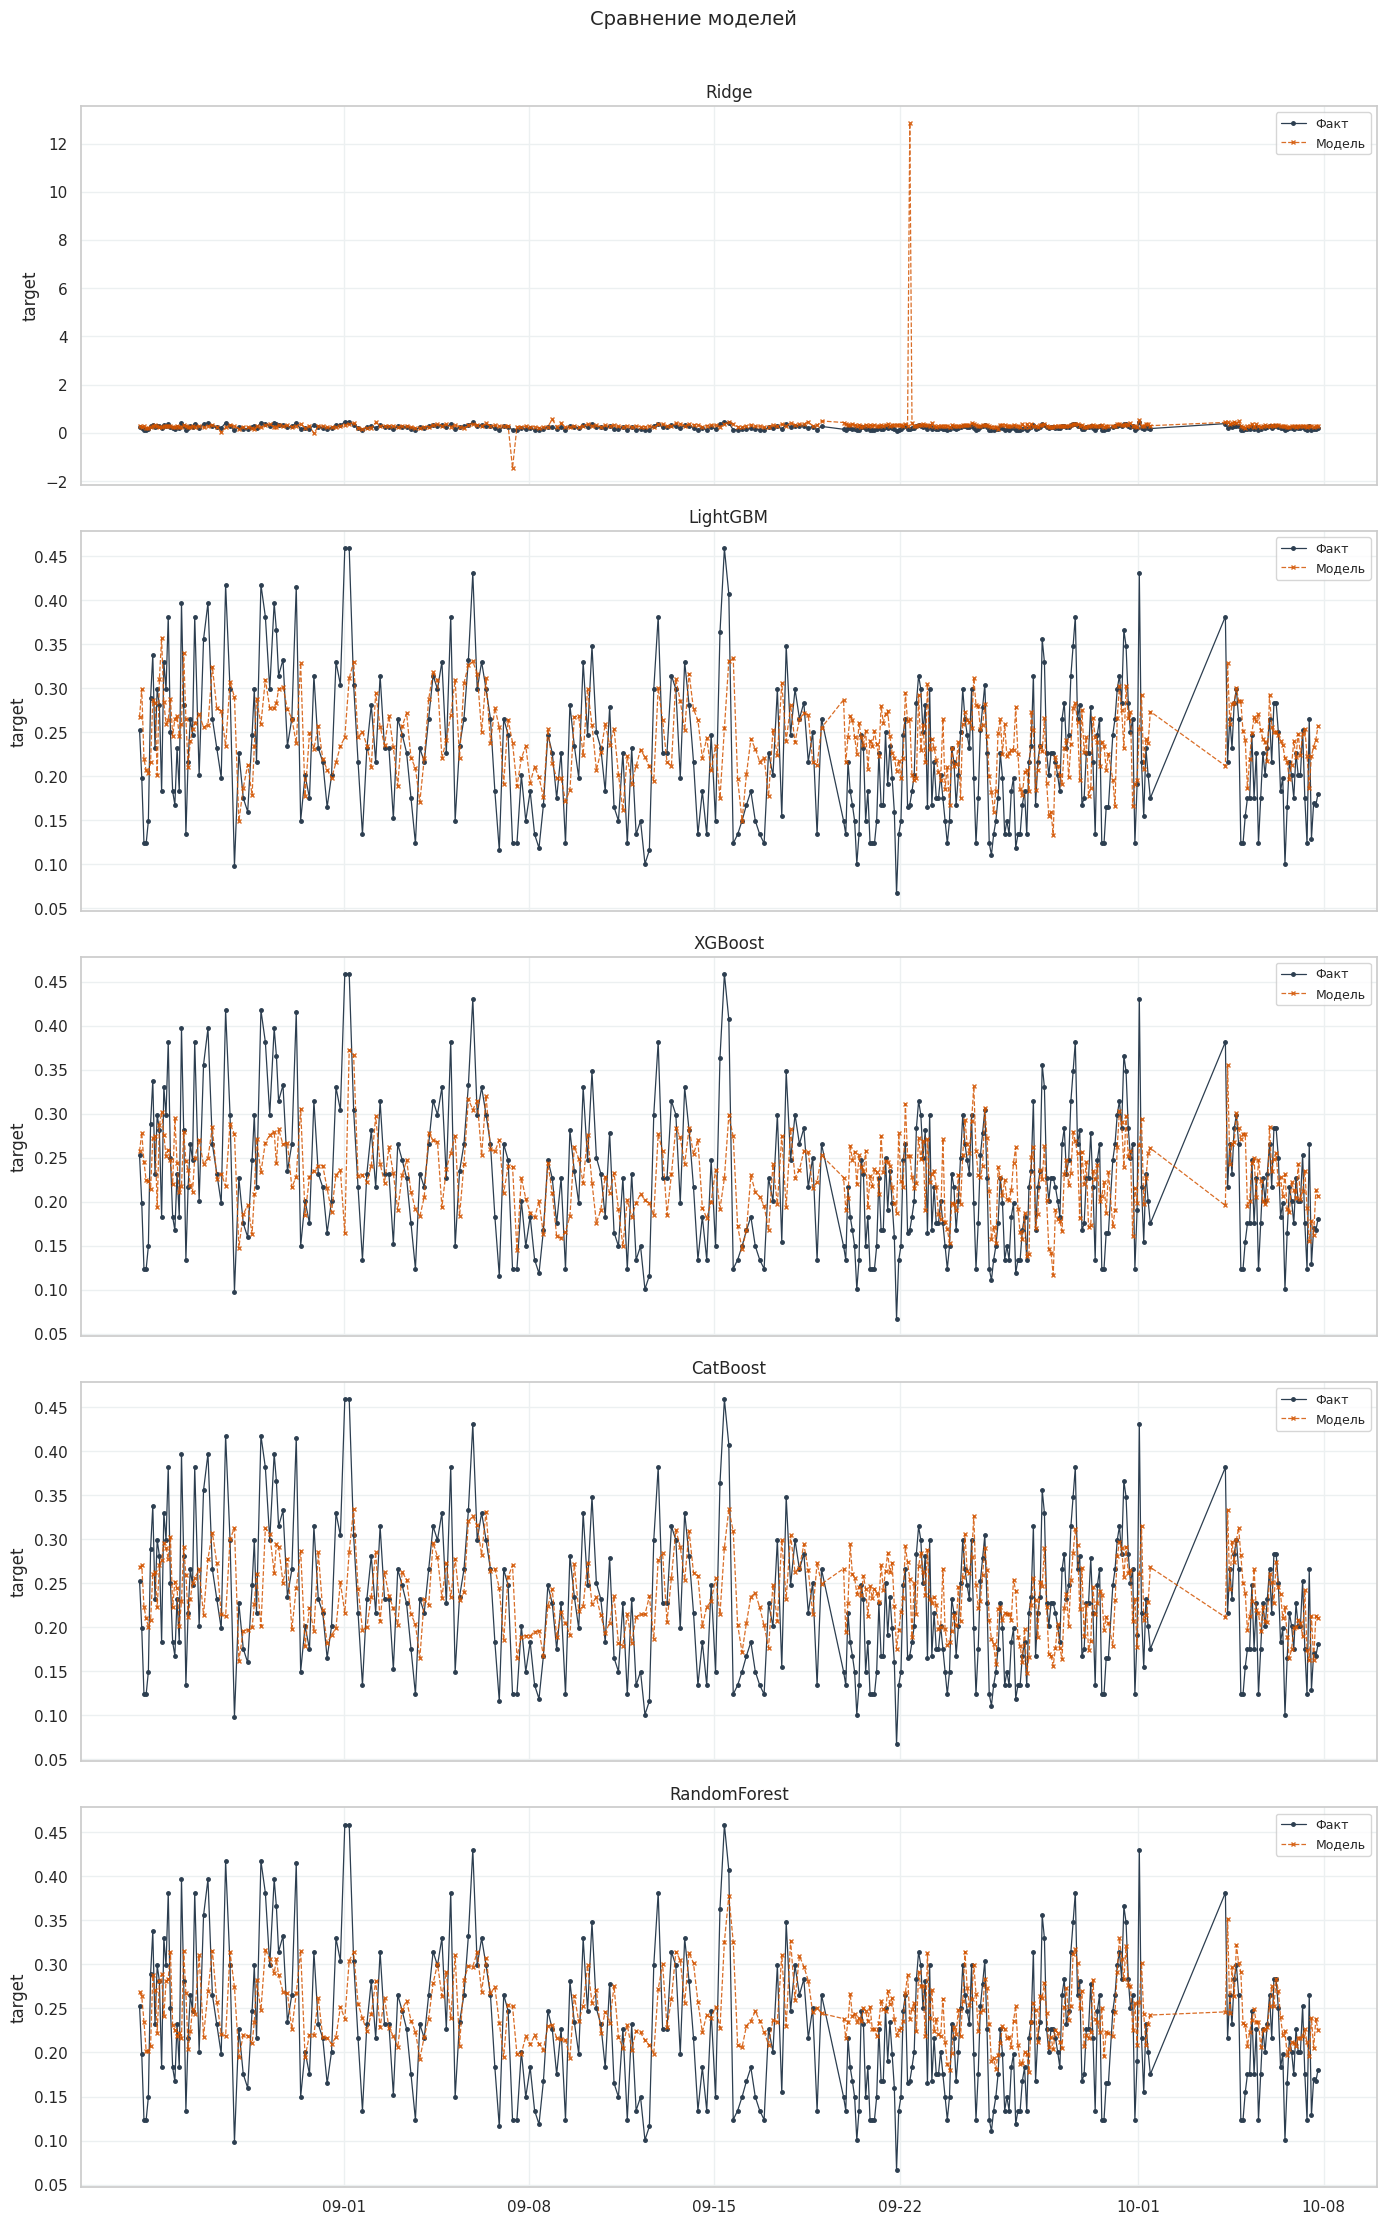

In [46]:
#  Визуализация: факт vs прогноз (отложенный тест)
fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=True)
series = [
    ("Ridge", y_pred_ridge),
    ("LightGBM", y_pred_lgb),
    ("XGBoost", y_pred_xgb),
    ("CatBoost", y_pred_cat),
    ("RandomForest", y_pred_rf),
]
for ax, (nm, pr) in zip(axes, series):
    ax.plot(y_test.index, y_test.values, "o-", ms=2.5, lw=0.9, label="Факт", color=COLOR_ACTUAL)
    ax.plot(y_test.index, pr, "x--", ms=2.5, lw=0.9, label="Модель", color=COLOR_PRED, alpha=0.85)
    ax.set_ylabel("target")
    ax.set_title(nm)
    ax.legend(loc="upper right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.suptitle(f"Сравнение моделей", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

1. **Лучшая точность прогноза** – у **CatBoost (Optuna)** (MAE = 0.0576, WAPE = 25.5%), он незначительно опережает XGBoost и LightGBM.
2. **Ridge Regression** значительно хуже (MAE = 0.1313, WAPE = 58.2%), подтверждая нелинейность зависимости (на предикте есть сильные выбросы, в предыдущих запусках график был больше похож на остальные модели).
3. **Directional Accuracy (DA)** всех моделей ~0.42–0.44, что **ниже случайного угадывания** (0.5) – модели систематически не улавливают направление изменений.
4. Все бустинговые модели показывают близкие результаты, но CatBoost лидирует по совокупности метрик.

## 2.4 Оценка качества моделей

Точечные метрики уже выведены; ниже — **остатки** лучшей по MAE модели, **направленность** (DA), **SHAP** и **permutation importance**, затем контроль на `test_small` и сравнение **AIC/BIC** (грубые surrogate) с **временем обучения/инференса**.


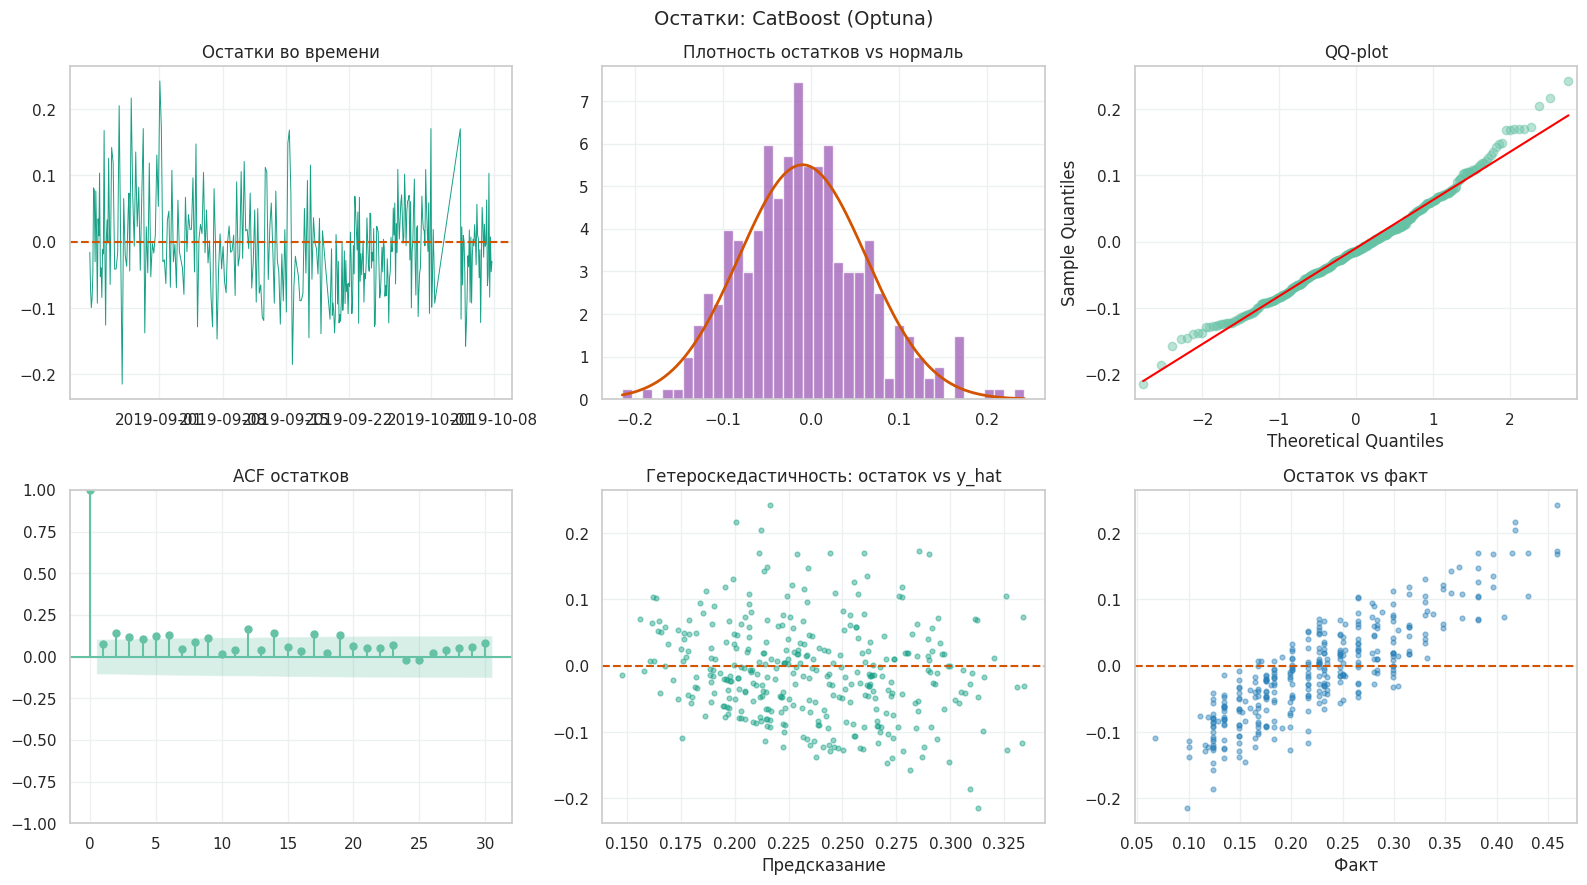

In [47]:
#  Выбор лучшей модели для анализа остатков
models_obj = {
    "LightGBM (Optuna)": (lgb_model, y_pred_lgb),
    "XGBoost (Optuna)": (xgb_model, y_pred_xgb),
    "CatBoost (Optuna)": (cat_model, y_pred_cat),
    "RandomForest (Optuna)": (rf_model, y_pred_rf),
}
best_name = summary["MAE"].idxmin()

best_model, y_best = models_obj[best_name]
shap_model = best_model

residuals = y_test.values - y_best

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes[0, 0].plot(y_test.index, residuals, "-", lw=0.7, color=COLOR_ACCENT)
axes[0, 0].axhline(0, color=COLOR_PRED, ls="--")
axes[0, 0].set_title("Остатки во времени")

axes[0, 1].hist(residuals, bins=40, density=True, alpha=0.75, color="#9b59b6", edgecolor="white")
xs = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].plot(xs, stats.norm.pdf(xs, residuals.mean(), residuals.std()), color=COLOR_PRED, lw=2)
axes[0, 1].set_title("Плотность остатков vs нормаль")

sm.qqplot(residuals, line="s", ax=axes[0, 2], alpha=0.45)
axes[0, 2].set_title("QQ-plot")

plot_acf(residuals, lags=30, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title("ACF остатков")

axes[1, 1].scatter(y_best, residuals, s=12, alpha=0.45, color=COLOR_ACCENT)
axes[1, 1].axhline(0, color=COLOR_PRED, ls="--")
axes[1, 1].set_xlabel("Предсказание")
axes[1, 1].set_title("Гетероскедастичность: остаток vs y_hat")

axes[1, 2].scatter(y_test.values, residuals, s=12, alpha=0.45, color="#2980b9")
axes[1, 2].axhline(0, color=COLOR_PRED, ls="--")
axes[1, 2].set_xlabel("Факт")
axes[1, 2].set_title("Остаток vs факт")

plt.suptitle(f"Остатки: {best_name}", fontsize=14)
plt.tight_layout()
plt.show()

In [49]:
n_sh = min(500, len(residuals))
_, p_sw = stats.shapiro(residuals[:n_sh])
jb = sm.stats.stattools.jarque_bera(residuals)
dw = durbin_watson(residuals)
X_bp = sm.add_constant(np.asarray(y_best).reshape(-1, 1))
_, p_bp, _, _ = het_breuschpagan(residuals, X_bp)

print("Shapiro p =", p_sw)
print("Jarque-Bera p =", jb[1])
print("Durbin-Watson =", dw)
print("Breusch-Pagan p =", p_bp)

Shapiro p = 0.004317296683576208
Jarque-Bera p = 0.00174790963957285
Durbin-Watson = 1.8127185327904636
Breusch-Pagan p = 0.012194832577249159


- нормальность отвергается
- нормальность отвергается
- наличие положительной автокорреляции (хотя не ососбо выраженной)
- гетероскедастичность (хотя при других запусках была гомоскедастичность)

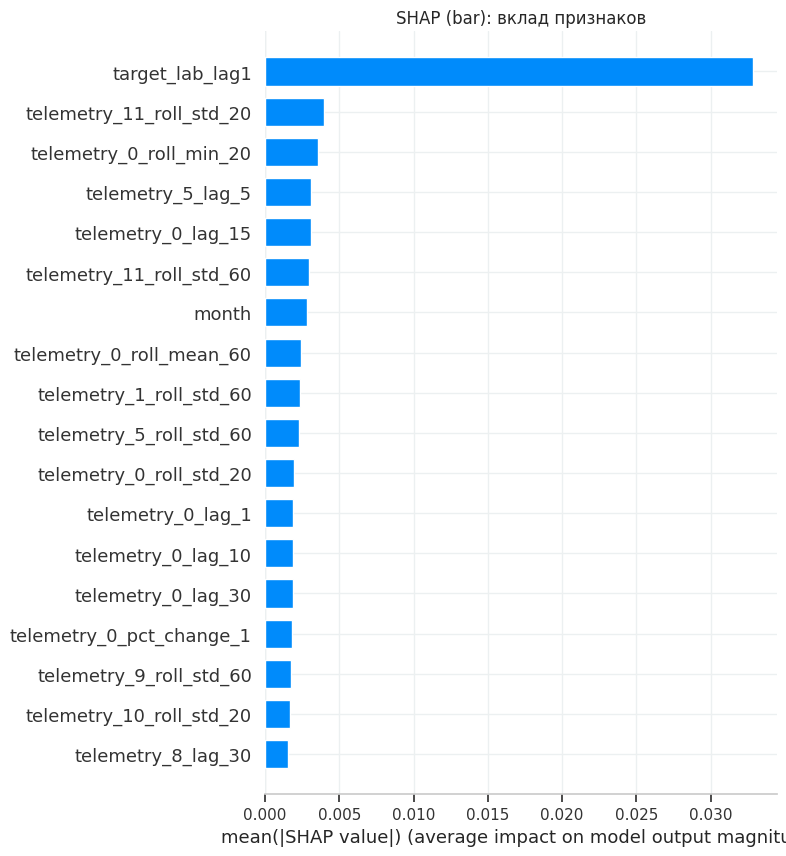

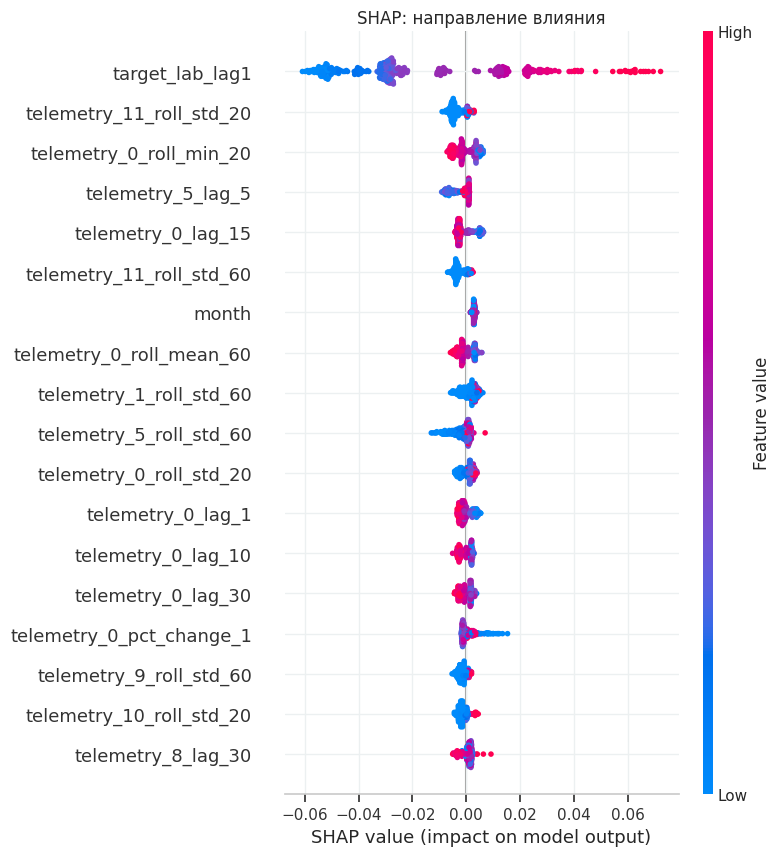

In [32]:
#  SHAP (дерево)
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, max_display=18, show=False, plot_type="bar")
plt.title("SHAP (bar): вклад признаков")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, max_display=18, show=False)
plt.title("SHAP: направление влияния")
plt.tight_layout()
plt.show()

то же самое что и в CatBoost: встроенная важность

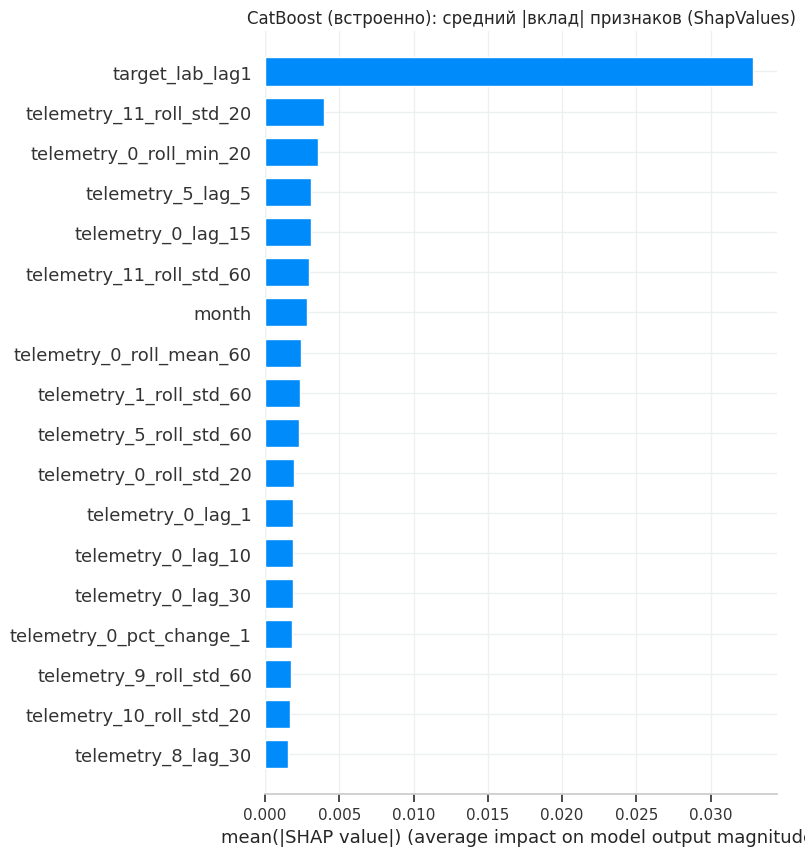

In [33]:
#  CatBoost: встроенная важность — визуализация как у SHAP
from catboost import Pool
pool_cb = Pool(data=X_test, label=y_test, feature_names=list(X_test.columns))
shap_cat_matrix = cat_model.get_feature_importance(data=pool_cb, type="ShapValues")
# последний столбец — bias / expected value модели на объекте
shap_cat_vals = shap_cat_matrix[:, :-1]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_cat_vals,
    X_test,
    max_display=18,
    show=False,
    plot_type="bar",
)
plt.title("CatBoost (встроенно): средний |вклад| признаков (ShapValues)")
plt.tight_layout()
plt.show()

                  feature     mean      std
          target_lab_lag1 0.011272 0.001450
 telemetry_11_roll_std_20 0.000302 0.000108
 telemetry_11_roll_std_60 0.000285 0.000140
 telemetry_10_roll_std_20 0.000261 0.000144
  telemetry_1_roll_std_60 0.000253 0.000187
  telemetry_3_roll_std_60 0.000247 0.000103
       telemetry_3_lag_30 0.000245 0.000120
  telemetry_1_roll_min_10 0.000194 0.000097
  telemetry_8_roll_std_20 0.000181 0.000080
  telemetry_3_roll_min_60 0.000144 0.000081
 telemetry_2_pct_change_1 0.000142 0.000046
  telemetry_2_roll_min_60 0.000128 0.000030
telemetry_11_roll_mean_60 0.000127 0.000063
  telemetry_3_roll_min_20 0.000124 0.000081
 telemetry_10_roll_max_20 0.000119 0.000045
  telemetry_5_roll_std_60 0.000118 0.000151
 telemetry_10_roll_std_60 0.000115 0.000081
       telemetry_9_lag_60 0.000115 0.000058
  telemetry_2_roll_std_20 0.000115 0.000070
       telemetry_6_lag_60 0.000114 0.000041


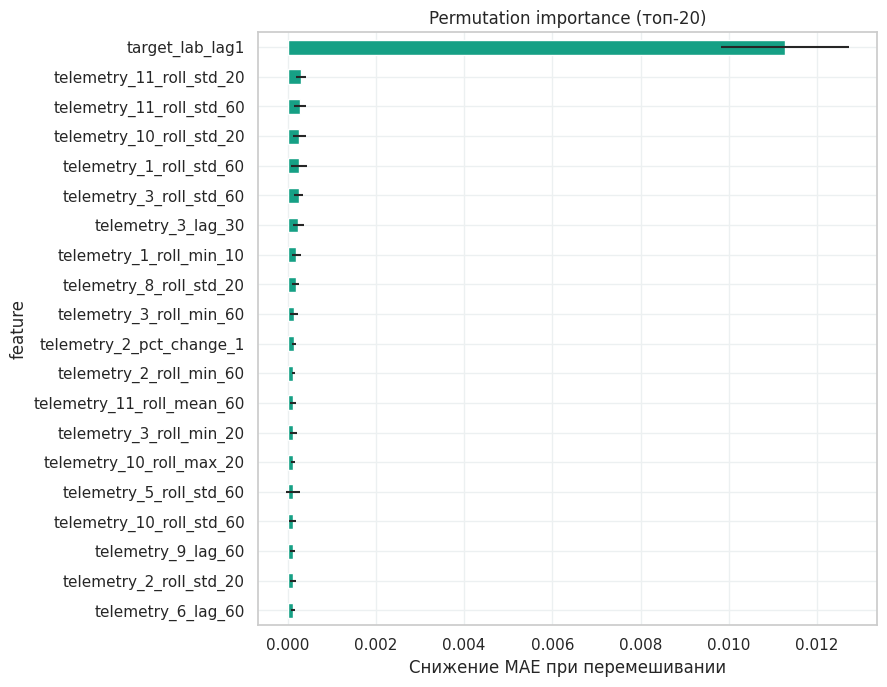

In [34]:
perm = permutation_importance(
    shap_model,
    X_test,
    y_test,
    n_repeats=12,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
)
perm_df = (
    pd.DataFrame({"feature": X_test.columns, "mean": perm.importances_mean, "std": perm.importances_std})
    .sort_values("mean", ascending=False)
    .head(20)
)
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
perm_df.sort_values("mean").plot(kind="barh", x="feature", y="mean", xerr="std", ax=ax, legend=False, color=COLOR_ACCENT)
ax.set_xlabel("Снижение MAE при перемешивании")
plt.title("Permutation importance (топ-20)")
plt.tight_layout()
plt.show()


In [35]:
#  test_small
telemetry_te = data_test[[c for c in keep_cols if c in data_test.columns]].copy()
telemetry_te = data_test[[c for c in keep_cols if c in data_test.columns]].copy()
telemetry_te = telemetry_te.groupby(telemetry_te.index, sort=True).mean(numeric_only=True)
for c in telemetry_te.columns:
    telemetry_te[c] = telemetry_te[c].interpolate(method="linear", limit=10)
for col in telemetry_te.columns:
    lo = telemetry[col].quantile(0.005)
    hi = telemetry[col].quantile(0.995)
    telemetry_te[col] = telemetry_te[col].clip(lo, hi)
if "telemetry_4" in telemetry_te.columns:
    telemetry_te["telemetry_4"] = telemetry_te["telemetry_4"].fillna(telemetry["telemetry_4"].median())

X_ext, y_ext = build_supervised_dataset(
    telemetry_te,
    target_test.sort_index(),
    best_delay,
    CONFIG["lag_list_min"],
    CONFIG["rolling_windows_min"],
    telemetry_cols_used,
    rolling_stats=("mean", "std", "min", "max"),
    include_derivatives=True,
)
for k in (1, 2, 3):
    X_ext[f"target_lab_lag{k}"] = y_ext.shift(k)
X_ext = X_ext.join(y_ext.rename("yy"))
X_ext = X_ext.loc[X_ext.notna().all(axis=1)].drop(columns=["yy"])
y_ext = y_ext.loc[X_ext.index]

last_train_tail = y_train.iloc[-3:].values
if len(X_ext) >= 1:
    X_ext.iloc[0, X_ext.columns.get_loc("target_lab_lag1")] = last_train_tail[-1]
    if "target_lab_lag2" in X_ext.columns:
        X_ext.iloc[0, X_ext.columns.get_loc("target_lab_lag2")] = last_train_tail[-2]
    if "target_lab_lag3" in X_ext.columns:
        X_ext.iloc[0, X_ext.columns.get_loc("target_lab_lag3")] = last_train_tail[-3]

for col in feature_cols:
    if col not in X_ext.columns:
        X_ext[col] = np.nan
X_ext = X_ext[feature_cols]
if X_ext.isnull().any().any():
    X_ext = X_ext.fillna(X_train.median())

y_ext_pred = best_model.predict(X_ext)
res_ext = evaluate("CatBoost — test_small", y_ext, y_ext_pred)


CatBoost — test_small
  MAE=0.05559 RMSE=0.07099 MAPE=0.30211 WAPE=0.26466 DA=0.4185


критерии AIC и BIC вычисляются двумя разными способами: классическим (через логарифм правдоподобия) для линейной модели Ridge и упрощённым (через RSS) для ансамблевых моделей

               AIC        BIC  train_s  infer_s
Ridge      1233.84    2192.02     0.06     0.00
LightGBM  86993.50  258538.73    14.49     0.06
XGBoost    -623.29    1694.89     2.01     0.02
CatBoost  14150.57   45044.16    50.41     0.01
RF         7179.97   24608.81    30.60     0.13


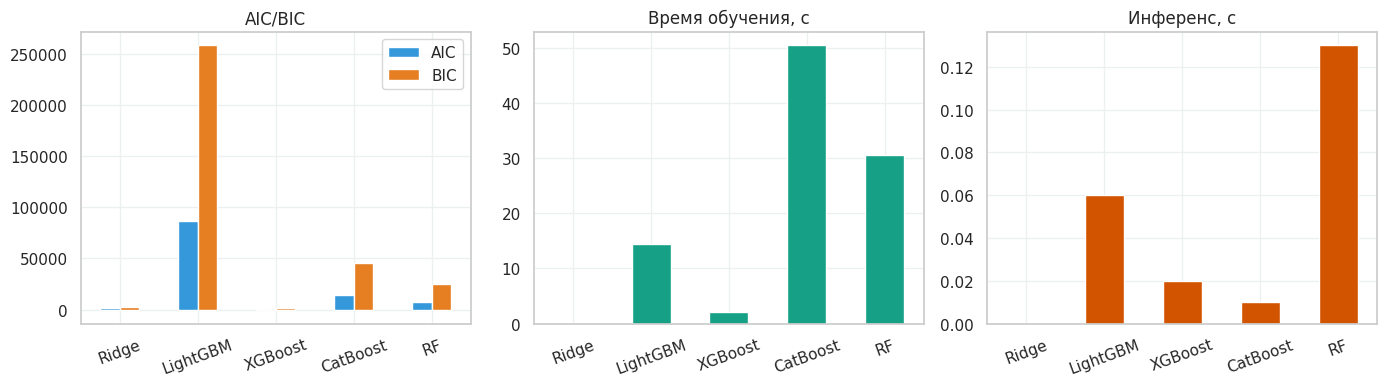

In [50]:
#  AIC/BIC и время
n = len(y_test)


def normal_ll(y_true, y_pred):
    resid = y_true - y_pred
    rss = float(np.sum(resid ** 2))
    s2 = rss / max(len(y_true), 1)
    ll = -0.5 * n * np.log(2 * np.pi * s2) - rss / (2 * s2)
    return ll, rss


def tree_ic(y_true, y_pred, k_eff):
    rss = np.sum((y_true - y_pred) ** 2)
    aic = n * np.log(rss / n + 1e-12) + 2 * k_eff
    bic = n * np.log(rss / n + 1e-12) + k_eff * np.log(n)
    return aic, bic


ll_r, rss_r = normal_ll(y_test.values, y_pred_ridge)
k_r = int(np.sum(np.abs(ridge.coef_) > 1e-6)) + 1
aic_r = 2 * k_r - 2 * ll_r
bic_r = np.log(n) * k_r - 2 * ll_r

k_lgb = int(lgb_model.best_iteration_ or 100) * int(lgb_model.get_params().get("num_leaves", 31))
k_xgb = int(getattr(xgb_model, "best_iteration", None) or 100) * int(xgb_model.get_params().get("max_depth", 5)) * 2
k_cat = int(cat_model.get_best_iteration() or 100) * int(cat_model.get_params().get("depth", 6))
k_rf = int(rf_model.n_estimators) * int(rf_model.max_depth or 1)

timing = {}
t0 = time.time()
Ridge(alpha=6.0).fit(X_train_sc, y_train)
timing["Ridge_fit"] = time.time() - t0
t0 = time.time()
ridge.predict(X_test_sc)
timing["Ridge_infer"] = time.time() - t0

def time_fit_predict(m, fit_kw=None, pred=None):
    fit_kw = fit_kw or {}
    t0 = time.time()
    if pred is None:
        m.fit(X_train, y_train, **fit_kw)
    else:
        m.fit(X_train, y_train, **fit_kw)
    tf = time.time() - t0
    t0 = time.time()
    m.predict(X_test)
    ti = time.time() - t0
    return tf, ti

# переобучаем копии для честного времени без early stopping callbacks в fit
lg = lgb.LGBMRegressor(**{**lgb_model.get_params(), "n_estimators": int(lgb_model.best_iteration_ or 200)})
tf, ti = time_fit_predict(lg)
timing["LGBM_fit"], timing["LGBM_infer"] = tf, ti

xg = xgb.XGBRegressor(
    **{**xgb_model.get_params(), "n_estimators": int(getattr(xgb_model, "best_iteration", 200) or 200)}
)
tf, ti = time_fit_predict(xg)
timing["XGB_fit"], timing["XGB_infer"] = tf, ti

cm = CatBoostRegressor(
    **{**cat_model.get_params(), "iterations": int(cat_model.get_best_iteration() or 200)}
)
tf, ti = time_fit_predict(cm)
timing["CAT_fit"], timing["CAT_infer"] = tf, ti

rf2 = RandomForestRegressor(**rf_model.get_params())
tf, ti = time_fit_predict(rf2)
timing["RF_fit"], timing["RF_infer"] = tf, ti

aic_l, bic_l = tree_ic(y_test.values, y_pred_lgb, k_lgb)
aic_x, bic_x = tree_ic(y_test.values, y_pred_xgb, k_xgb)
aic_c, bic_c = tree_ic(y_test.values, y_pred_cat, k_cat)
aic_f, bic_f = tree_ic(y_test.values, y_pred_rf, k_rf)

ic_df = pd.DataFrame(
    {
        "AIC": [aic_r, aic_l, aic_x, aic_c, aic_f],
        "BIC": [bic_r, bic_l, bic_x, bic_c, bic_f],
        "train_s": [timing["Ridge_fit"], timing["LGBM_fit"], timing["XGB_fit"], timing["CAT_fit"], timing["RF_fit"]],
        "infer_s": [timing["Ridge_infer"], timing["LGBM_infer"], timing["XGB_infer"], timing["CAT_infer"], timing["RF_infer"]],
    },
    index=["Ridge", "LightGBM", "XGBoost", "CatBoost", "RF"],
).round(2)
print(ic_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ic_df[["AIC", "BIC"]].plot(kind="bar", ax=axes[0], rot=20, color=["#3498db", "#e67e22"])
axes[0].set_title("AIC/BIC")
ic_df["train_s"].plot(kind="bar", ax=axes[1], color=COLOR_ACCENT, rot=20)
axes[1].set_title("Время обучения, с")
ic_df["infer_s"].plot(kind="bar", ax=axes[2], color=COLOR_PRED, rot=20)
axes[2].set_title("Инференс, с")
plt.tight_layout()
plt.show()


Сравнение корректно отдельно, но не напрямую между деревьями и Ridge.

Для деревьев – это приближённые критерии, так как:

- Такие модели не являются параметрическими в классическом смысле.
- Эффективное число параметров оценивается грубо.

### По информационным критериям

- **XGBoost** показывает экстремально низкий AIC (–623.29), что формально указывает на наилучший баланс качества и сложности. Однако для деревьев решений AIC/BIC некорректно учитывают число параметров (фактически — количество листьев и глубину), поэтому эти критерии не являются определяющими.
- **CatBoost** имеет высокие значения AIC/BIC (14150 / 45044), но именно он достигает лучшей точности прогноза. Как и в случае с LightGBM в предыдущем анализе, информационные критерии штрафуют сложную ансамблевую структуру, недооценивая реальную обобщающую способность.
- **Ridge** минимизирует AIC/BIC (1234 / 2192) за счёт малого числа параметров, но качество регрессии неприемлемо низкое (WAPE=58.2%) — линейная модель не способна описать нелинейные зависимости процесса.

### По вычислительной эффективности

- **Ridge**: обучение ~0.06 с, инференс ~0.00 с — мгновенно, но бесполезно из-за низкого качества.
- **XGBoost**: обучение 2.01 с, инференс 0.02 с — очень быстр, качество близко к лучшему.
- **LightGBM**: обучение 14.5 с, инференс 0.06 с — приемлемо, но уступает CatBoost по точности.
- **CatBoost**: обучение 50.4 с (самый долгий этап обучения), однако инференс 0.01 с — один из самых быстрых в production. Для real‑time soft sensor это критично: обучение проводится один раз, а предсказания должны поступать за миллисекунды.
- **Random Forest**: обучение 30.6 с, инференс 0.13 с — самый медленный на обоих этапах, без выигрыша в качестве.

**Итог:** CatBoost остаётся лучшим выбором — высшая точность прогноза (MAE=0.0576, WAPE=25.5%) при минимальном времени инференса (0.01 с), что делает его оптимальным для промышленного real‑time датчика.


**Остатки модели CatBoost** не удовлетворяют критерию нормальности, однако визуально распределение близко к нормальному с утяжелёнными хвостами. Это объясняется наличием нештатных режимов, которые модель предсказывает с систематической ошибкой. **Главная проблема** – **Directional Accuracy (DA) около 0.43–0.44, что ниже случайного угадывания (0.5)**. Модель систематически не улавливает направление изменения концентрации, хотя абсолютная ошибка (MAE) невелика. Это указывает на то, что предсказания «сглажены» и не отслеживают резкие повороты тренда.

---

### Интерпретация ключевых признаков (на основе анализа важности)

- **target_lag1** – доминирующий предиктор (инерционность процесса). Концентрация продукта в текущий момент почти полностью определяется предыдущим значением, что физически обоснованно для термохимических реакторов с большой постоянной времени.
- **telemetry_0** – ключевой датчик интенсивности процесса. Его скользящие минимум за 20 периодов (`roll_min_20`) и лагированное значение (`lag_15`) важнее мгновенных показаний. Это говорит о том, что процесс инерционен по отношению к этому каналу.
- **telemetry_11** – статистики разброса (`roll_std_20`, `roll_std_60`) влияют на концентрацию. Рост стандартного отклонения предшествует нестабильному режиму и последующему изменению продукта.
- **telemetry_5** – лагированное значение (`lag_5`) входит в топ предикторов.
- **month** – сезонный признак присутствует в списке. Это подтверждает, что режим работы печи (температура окружающей среды, свойства сырья) различается по месяцам и должно учитываться моделью.

### Краткие общие выводы по работе

- Построен и сравнен набор моделей для задачи виртуального датчика; линейный подход (Ridge) показал недостаточное качество, тогда как бустинговые модели существенно лучше описывают нелинейную динамику процесса.
- Наилучший практический баланс точности и скорости инференса получен у **CatBoost**, поэтому он выбран как основной кандидат для промышленного real-time применения.
- Анализ ошибок показал, что модель хорошо снижает абсолютную ошибку, но хуже отслеживает направление краткосрочных изменений (низкий DA), что указывает на необходимость дальнейшей доработки признаков/целевой постановки под directional-метрики.
- Ключевую роль играют лаги целевой переменной и статистики телеметрии, что подтверждает инерционность технологического процесса и важность временного контекста.
- Для подбора гиперпараметров использовалась **Optuna**, что позволило системно и эффективно найти более сильные конфигурации моделей по сравнению с ручной настройкой.